# This notebook is to read and make plots from information extracted on the logs

## 0 - Imports

In [5]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

## 1 - Plot general CPU time and memory used in whole computation

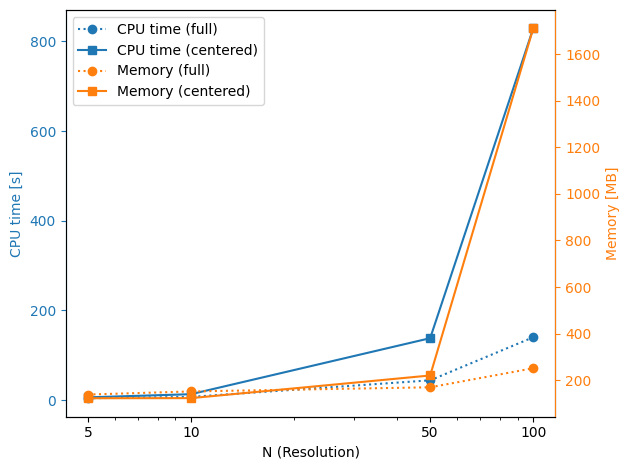

In [38]:
# Read data
df = pd.read_csv("exactBO_logs/initialExperiments_time_memory.csv")

# Convert CPU time to seconds (or minutes if you prefer)
df["CPU_seconds"] = pd.to_timedelta(df["CPU time (h:m:s)"]).dt.total_seconds()

# Sort by N
df = df.sort_values("N")

# Marker for each split_type
markers = {
    "full": "o",
    "centered": "s"
}

# Linestyle for each split_type
linestyle = {
    "full": ":",
    "centered": "-"
}

# Colors per y-axis
time_color = "tab:blue"
mem_color = "tab:orange"

fig, ax_time = plt.subplots()

# Second y-axis for memory
ax_mem = ax_time.twinx()

for split in df["split_type"].unique():
    sub = df[df["split_type"] == split]
    m = markers.get(split, "o")
    ls = linestyle.get(split, "-")

    # CPU time (left axis, time_color)
    ax_time.plot(
        sub["N"],
        sub["CPU_seconds"],
        marker=m,
        linestyle=ls,
        color=time_color,
        label=f"CPU time ({split})"
    )

    # Memory (right axis, mem_color)
    ax_mem.plot(
        sub["N"],
        sub["memory (MB)"],
        marker=m,
        linestyle=ls,
        color=mem_color,
        label=f"Memory ({split})"
    )

# Axis labels
ax_time.set_xlabel("N (Resolution)")
ax_time.set_xscale("log")
ax_time.set_ylabel("CPU time [s]", color=time_color)
ax_mem.set_ylabel("Memory [MB]", color=mem_color)
ax_time.set_xticks([5, 10, 50, 100])
ax_time.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_time.get_xaxis().set_minor_formatter(plt.NullFormatter())

# Color axes, ticks and labels
ax_time.tick_params(axis="y", colors=time_color)
ax_mem.tick_params(axis="y", colors=mem_color)
ax_time.spines["left"].set_color(time_color)
ax_mem.spines["right"].set_color(mem_color)
ax_time.yaxis.label.set_color(time_color)
ax_mem.yaxis.label.set_color(mem_color)

# Combined legend
handles1, labels1 = ax_time.get_legend_handles_labels()
handles2, labels2 = ax_mem.get_legend_handles_labels()
ax_time.legend(handles1 + handles2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()


## 2 - Plot average time per iteration

In [30]:
res_exp1 = {"N":[],"split_type":[],"precision":[],"res_x_EBO":[],"res_x_BO":[],"res_x_Opt":[]}
for it in range(10):
    key = f"ebo_it{it}"
    for m in ["timeBO", "timeEBO", "best_x_BO", "best_x_EBO"]:
        key_m = key + "_" + m
        res_exp1[key_m] = []

Ns = [5,10,50,100]
split_types = ["full", "centered"]
for N in Ns:
    for split_type in split_types:
        with open(f"exactBO_logs/exactBO_log_N{N}_{split_type}.pkl", "rb") as f:
            ebolog = pickle.load(f)
            res_exp1["N"].append(N)
            res_exp1["split_type"].append(split_type)
            
            precision = ebolog['start']['precision']
            res_exp1["precision"].append(precision)           
            for it in range(10):
                key = f"ebo_it{it}"
                timeBO = ebolog[key]['compare']['timeBO']
                res_exp1[key+"_timeBO"].append(timeBO)

                timeEBO = ebolog[key]['compare']['timeEBO']
                res_exp1[key+"_timeEBO"].append(timeEBO)

                best_x_BO = ebolog[key]['compare']['best_x_BO']
                res_exp1[key+"_best_x_BO"].append(best_x_BO)

                best_x_EBO = ebolog[key]['compare']['best_x_EBO']
                res_exp1[key+"_best_x_EBO"].append(best_x_BO)           
            res_x_EBO = ebolog['result']['EBO'].X_opt
            res_exp1["res_x_EBO"].append(res_x_EBO)
            
            res_x_BO = ebolog['result']['BO'].X_opt
            res_exp1["res_x_BO"].append(res_x_BO)

            res_x_Opt = ebolog['result']['Opt'].X_opt
            res_exp1["res_x_Opt"].append(res_x_Opt)

df_res_exp1 = pd.DataFrame(res_exp1)

In [31]:
df_res_exp1

,N,split_type,precision,res_x_EBO,res_x_BO,res_x_Opt,ebo_it0_timeBO,ebo_it0_timeEBO,ebo_it0_best_x_BO,ebo_it0_best_x_EBO,...,ebo_it7_best_x_BO,ebo_it7_best_x_EBO,ebo_it8_timeBO,ebo_it8_timeEBO,ebo_it8_best_x_BO,ebo_it8_best_x_EBO,ebo_it9_timeBO,ebo_it9_timeEBO,ebo_it9_best_x_BO,ebo_it9_best_x_EBO
0,5,full,"[0.25, 0.25]","[1.0, 0.25]","[1.0, 0.25]","[0.8978978978978979, 0.29929929929929927]",0.000523,0.031773,"[0.75, 0.0]","[0.75, 0.0]",...,"[1.0, 0.5]","[1.0, 0.5]",0.000360,0.005858,"[0.75, 0.25]","[0.75, 0.25]",0.000345,0.004362,"[0.25, 0.75]","[0.25, 0.75]"
1,5,centered,"[0.25, 0.25]","[0.9296875, 0.3046875]","[1.0, 0.25]","[0.8978978978978979, 0.29929929929929927]",0.000517,0.093393,"[0.75, 0.0]","[0.75, 0.0]",...,"[1.0, 0.5]","[1.0, 0.5]",0.000364,0.161604,"[0.75, 0.25]","[0.75, 0.25]",0.000356,0.170004,"[0.25, 0.75]","[0.25, 0.75]"
2,10,full,"[0.1111111111111111, 0.1111111111111111]","[0.90625, 0.28125]","[0.8888888888888888, 0.3333333333333333]","[0.8978978978978979, 0.29929929929929927]",0.000548,0.205375,"[0.8888888888888888, 0.1111111111111111]","[0.8888888888888888, 0.1111111111111111]",...,"[0.4444444444444444, 0.0]","[0.4444444444444444, 0.0]",0.000380,0.500589,"[0.8888888888888888, 0.5555555555555556]","[0.8888888888888888, 0.5555555555555556]",0.000373,0.530423,"[0.2222222222222222, 0.3333333333333333]","[0.2222222222222222, 0.3333333333333333]"
3,10,centered,"[0.1111111111111111, 0.1111111111111111]","[0.8857421875, 0.3046875]","[0.8888888888888888, 0.3333333333333333]","[0.8978978978978979, 0.29929929929929927]",0.000538,0.327500,"[0.8888888888888888, 0.1111111111111111]","[0.8888888888888888, 0.1111111111111111]",...,"[0.4444444444444444, 0.0]","[0.4444444444444444, 0.0]",0.000368,1.445372,"[0.8888888888888888, 0.5555555555555556]","[0.8888888888888888, 0.5555555555555556]",0.000374,1.579269,"[0.2222222222222222, 0.3333333333333333]","[0.2222222222222222, 0.3333333333333333]"
4,50,full,"[0.02040816326530612, 0.02040816326530612]","[0.8984375, 0.3046875]","[0.8979591836734693, 0.3061224489795918]","[0.8978978978978979, 0.29929929929929927]",0.001017,0.812074,"[0.8571428571428571, 0.0]","[0.8571428571428571, 0.0]",...,"[0.44897959183673464, 0.9999999999999999]","[0.44897959183673464, 0.9999999999999999]",0.000991,8.355654,"[0.8979591836734693, 0.3061224489795918]","[0.8979591836734693, 0.3061224489795918]",0.001000,9.315434,"[0.3877551020408163, 0.0]","[0.3877551020408163, 0.0]"
5,50,centered,"[0.02040816326530612, 0.02040816326530612]","[0.8960418701171875, 0.3046875]","[0.8979591836734693, 0.3061224489795918]","[0.8978978978978979, 0.29929929929929927]",0.001055,1.707905,"[0.8571428571428571, 0.0]","[0.8571428571428571, 0.0]",...,"[0.44897959183673464, 0.9999999999999999]","[0.44897959183673464, 0.9999999999999999]",0.000957,22.714005,"[0.8979591836734693, 0.3061224489795918]","[0.8979591836734693, 0.3061224489795918]",0.000961,31.570508,"[0.3877551020408163, 0.0]","[0.3877551020408163, 0.0]"
6,100,full,"[0.010101010101010102, 0.010101010101010102]","[0.89453125, 0.30078125]","[0.8989898989898991, 0.30303030303030304]","[0.8978978978978979, 0.29929929929929927]",0.162557,2.483103,"[0.8686868686868687, 0.05050505050505051]","[0.8686868686868687, 0.05050505050505051]",...,"[0.0, 0.5454545454545455]","[0.0, 0.5454545454545455]",0.002984,20.876003,"[0.4545454545454546, 1.0]","[0.4545454545454546, 1.0]",0.002858,31.516804,"[0.8989898989898991, 0.31313131313131315]","[0.8989898989898991, 0.31313131313131315]"
7,100,centered,"[0.010101010101010102, 0.010101010101010102]","[0.9022216796875, 0.3046875]","[0.8989898989898991, 0.30303030303030304]","[0.8978978978978979, 0.29929929929929927]",6.147654,6.812446,"[0.8686868686868687, 0.05050505050505051]","[0.8686868686868687, 0.05050505050505051]",...,"[0.0, 0.5454545454545455]","[0.0, 0.5454545454545455]",0.002681,256.065592,"[0.4545454545454546, 1.0]","[0.4545454545454546, 1.0]",0.002837,249.412365,"[0.8989898989898991, 0.31313131313131315]","[0.8989898989898991, 0.31313

In [32]:
df_res_exp1.columns

Index(['N', 'split_type', 'precision', 'res_x_EBO', 'res_x_BO', 'res_x_Opt',
       'ebo_it0_timeBO', 'ebo_it0_timeEBO', 'ebo_it0_best_x_BO',
       'ebo_it0_best_x_EBO', 'ebo_it1_timeBO', 'ebo_it1_timeEBO',
       'ebo_it1_best_x_BO', 'ebo_it1_best_x_EBO', 'ebo_it2_timeBO',
       'ebo_it2_timeEBO', 'ebo_it2_best_x_BO', 'ebo_it2_best_x_EBO',
       'ebo_it3_timeBO', 'ebo_it3_timeEBO', 'ebo_it3_best_x_BO',
       'ebo_it3_best_x_EBO', 'ebo_it4_timeBO', 'ebo_it4_timeEBO',
       'ebo_it4_best_x_BO', 'ebo_it4_best_x_EBO', 'ebo_it5_timeBO',
       'ebo_it5_timeEBO', 'ebo_it5_best_x_BO', 'ebo_it5_best_x_EBO',
       'ebo_it6_timeBO', 'ebo_it6_timeEBO', 'ebo_it6_best_x_BO',
       'ebo_it6_best_x_EBO', 'ebo_it7_timeBO', 'ebo_it7_timeEBO',
       'ebo_it7_best_x_BO', 'ebo_it7_best_x_EBO', 'ebo_it8_timeBO',
       'ebo_it8_timeEBO', 'ebo_it8_best_x_BO', 'ebo_it8_best_x_EBO',
       'ebo_it9_timeBO', 'ebo_it9_timeEBO', 'ebo_it9_best_x_BO',
       'ebo_it9_best_x_EBO'],
      dtype='object')

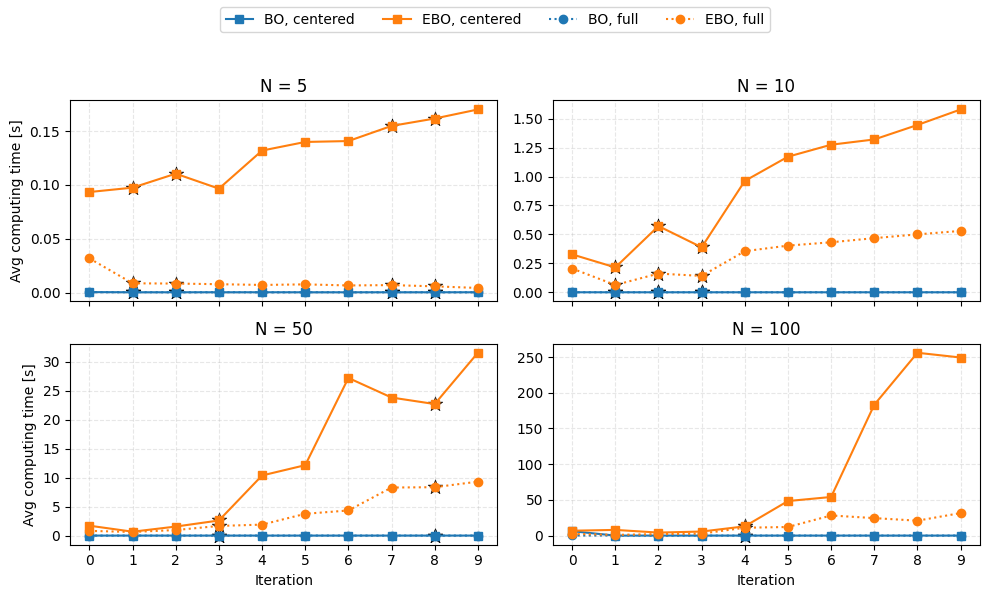

In [40]:
import numpy as np
import matplotlib.pyplot as plt

df = df_res_exp1.copy()
n_iters = 10  # it0 ... it9

# Colors per method
method_colors = {
    "BO": "tab:blue",
    "EBO": "tab:orange",
}

# Markers per split_type
marker_map = {
    "full": "o",
    "centered": "s",
}

# Markers per split_type
linestyles = {
    "full": ":",
    "centered": "-",
}

iters = np.arange(n_iters)
unique_N = sorted(df["N"].unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)  # no sharey
axes = axes.ravel()

for ax, N_val in zip(axes, unique_N):
    df_N = df[df["N"] == N_val]
    all_times_N = []  # collect times for this N to set y-limits

    for split_val, grp in df_N.groupby("split_type"):
        marker = marker_map.get(split_val, "o")
        ls = linestyles.get(split_val, "-")

        for method in ["BO", "EBO"]:
            color = method_colors[method]

            mean_times = []
            star_x, star_y = [], []

            for it in range(n_iters):
                col_time = f"ebo_it{it}_time{method}"
                col_best = f"ebo_it{it}_best_x_{method}"

                if col_time not in grp.columns or col_best not in grp.columns:
                    mean_times.append(np.nan)
                    continue

                mt = grp[col_time].mean()
                mean_times.append(mt)

                # Check within precision
                def within_precision(row):
                    best = np.array(row[col_best])
                    opt = np.array(row["res_x_Opt"])
                    prec = np.array(row["precision"])
                    return np.all(np.abs(best - opt) <= prec)

                if grp.apply(within_precision, axis=1).any():
                    star_x.append(it)
                    star_y.append(mt)

            mean_times = np.array(mean_times, dtype=float)
            all_times_N.append(mean_times)

            label = f"{method}, {split_val}"
            ax.plot(
                iters,
                mean_times,
                marker=marker,
                linestyle=ls,
                color=color,
                label=label,
            )

            if star_x:
                ax.scatter(
                    star_x,
                    star_y,
                    marker="*",
                    s=120,
                    color=color,
                    edgecolor="k",
                    linewidth=0.5,
                )

    # Set y-limits specific to this N (ignore NaNs)
    if all_times_N:
        all_times_N = np.concatenate(all_times_N)
        all_times_N = all_times_N[~np.isnan(all_times_N)]
        if all_times_N.size > 0:
            ymin = all_times_N.min()
            ymax = all_times_N.max()
            # add a bit of padding
            pad = 0.05 * (ymax - ymin if ymax > ymin else ymax or 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_title(f"N = {N_val}")
    ax.grid(True, linestyle="--", alpha=0.3)

for ax in axes:
    ax.set_xticks(iters)

axes[2].set_xlabel("Iteration")
axes[3].set_xlabel("Iteration")
axes[0].set_ylabel("Avg computing time [s]")
axes[2].set_ylabel("Avg computing time [s]")

# Global legend (methods & split_type)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


In [42]:
with open("exactBO_logs/exactBO_log_N100_full.pkl", "rb") as f:
    ebolog = pickle.load(f)

In [51]:
len(ebolog['ebo_it0']['ploop_7']['boxes'].items)

1684

In [53]:
L = np.array([1,2,3])
R = np.array([3,4,5])
xi = np.array([2,5,6])

np.maximum(L-xi,0)

array([0, 0, 0])